# 从城市房地产开发和销售角度分析 gap_to_gdp 的地区差异和时序特征

本notebook从城市房地产开发和销售的角度分析财政缺口与GDP比率（gap_to_gdp）的地区差异和时序特征。通过整合财政数据和房地产数据，进行探索性数据分析、相关性分析和可视化。

## 1. 数据加载和准备

加载财政数据（cleaned_panel_data_v2.csv）和房地产数据（cleaned_real_estate_merged.csv），处理数据类型，检查缺失值。

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置matplotlib支持中文
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 设置中文字体，优先使用SimHei
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# Load fiscal data
fiscal_df = pd.read_csv('data_clean/cleaned_panel_data_v2.csv')
print("Fiscal data shape:", fiscal_df.shape)
print("Fiscal data columns:", fiscal_df.columns.tolist())
print("Fiscal data head:")
print(fiscal_df.head())

# Load real estate data
real_estate_df = pd.read_csv('data_clean/cleaned_real_estate_merged.csv')
print("\nReal estate data shape:", real_estate_df.shape)
print("Real estate data columns:", real_estate_df.columns.tolist())
print("Real estate data head:")
print(real_estate_df.head())

# Check for missing values
print("\nMissing values in fiscal data:")
print(fiscal_df.isnull().sum())
print("\nMissing values in real estate data:")
print(real_estate_df.isnull().sum())

Fiscal data shape: (684, 6)
Fiscal data columns: ['城市', '年度', '财政收入(亿元)', '财政支出(亿元)', '住户存款余额(亿元)', '地区生产总值(亿元)']
Fiscal data head:
   城市    年度  财政收入(亿元)  财政支出(亿元)  住户存款余额(亿元)  地区生产总值(亿元)
0  上海  2006   1576.07   1795.57     8730.00     10825.4
1  上海  2007   2074.48   2181.68     8745.22     13179.8
2  上海  2008   2358.75   2593.92    11464.15     14877.1
3  上海  2009   2540.30   2989.65    13707.32     16181.4
4  上海  2010   2873.58   3302.89    15650.24     18319.6

Real estate data shape: (665, 6)
Real estate data columns: ['地区', '年份', '商品房销售面积', '商品房销售额', '房地产开发投资额', '房地产施工面积']
Real estate data head:
   地区    年份  商品房销售面积   商品房销售额  房地产开发投资额   房地产施工面积
0  上海  2006  3025.40  3025.40   1275.59  10938.75
1  上海  2007  3694.96  3694.96   1307.53  10766.72
2  上海  2008  2339.29  2339.29   1435.73  10784.23
3  上海  2009  3372.45  3372.45   1462.07   9949.45
4  上海  2010  2060.96  2060.96   1980.68  11295.03

Missing values in fiscal data:
城市            0
年度            0
财政收入(亿元)      0
财政支出(亿元)    

## 2. 数据合并

将财政数据和房地产数据基于城市和年份合并。

In [12]:
# Rename columns for consistency
fiscal_df = fiscal_df.rename(columns={'城市': '地区', '年度': '年份'})

# Merge on '地区' and '年份'
merged_df = pd.merge(fiscal_df, real_estate_df, on=['地区', '年份'], how='inner')
print("Merged data shape:", merged_df.shape)
print("Merged data columns:", merged_df.columns.tolist())
print("Merged data head:")
print(merged_df.head())

# Check for duplicates
print("\nDuplicates in merged data:", merged_df.duplicated().sum())

Merged data shape: (665, 10)
Merged data columns: ['地区', '年份', '财政收入(亿元)', '财政支出(亿元)', '住户存款余额(亿元)', '地区生产总值(亿元)', '商品房销售面积', '商品房销售额', '房地产开发投资额', '房地产施工面积']
Merged data head:
   地区    年份  财政收入(亿元)  财政支出(亿元)  住户存款余额(亿元)  地区生产总值(亿元)  商品房销售面积   商品房销售额  \
0  上海  2006   1576.07   1795.57     8730.00     10825.4  3025.40  3025.40   
1  上海  2007   2074.48   2181.68     8745.22     13179.8  3694.96  3694.96   
2  上海  2008   2358.75   2593.92    11464.15     14877.1  2339.29  2339.29   
3  上海  2009   2540.30   2989.65    13707.32     16181.4  3372.45  3372.45   
4  上海  2010   2873.58   3302.89    15650.24     18319.6  2060.96  2060.96   

   房地产开发投资额   房地产施工面积  
0   1275.59  10938.75  
1   1307.53  10766.72  
2   1435.73  10784.23  
3   1462.07   9949.45  
4   1980.68  11295.03  

Duplicates in merged data: 0


## 3. 探索性数据分析 (EDA)

对合并数据集进行初步探索，包括汇总统计、关键变量分布。

Summary statistics:
                年份     财政收入(亿元)     财政支出(亿元)    住户存款余额(亿元)    地区生产总值(亿元)  \
count   665.000000   665.000000   665.000000    665.000000    665.000000   
mean   2015.000000   921.088483  1229.456549   7130.667785   8315.163549   
std       5.481348  1247.839940  1539.076518   8601.148867   8552.353907   
min    2006.000000    14.160000    32.250000     88.650000    281.610000   
25%    2010.000000   238.140000   353.050000   2174.090000   2801.000000   
50%    2015.000000   500.180000   758.640000   4348.550000   5576.000000   
75%    2020.000000  1060.820000  1365.290000   8730.000000  10749.200000   
max    2024.000000  8374.170000  9874.840000  70398.150000  53759.500000   

           商品房销售面积       商品房销售额     房地产开发投资额       房地产施工面积  
count   665.000000   665.000000   665.000000    665.000000  
mean   1218.449008  1218.449008  1227.709429   7185.677624  
std     967.585925   967.585925  1100.776116   5034.654835  
min     100.210000   100.210000    29.380000    418

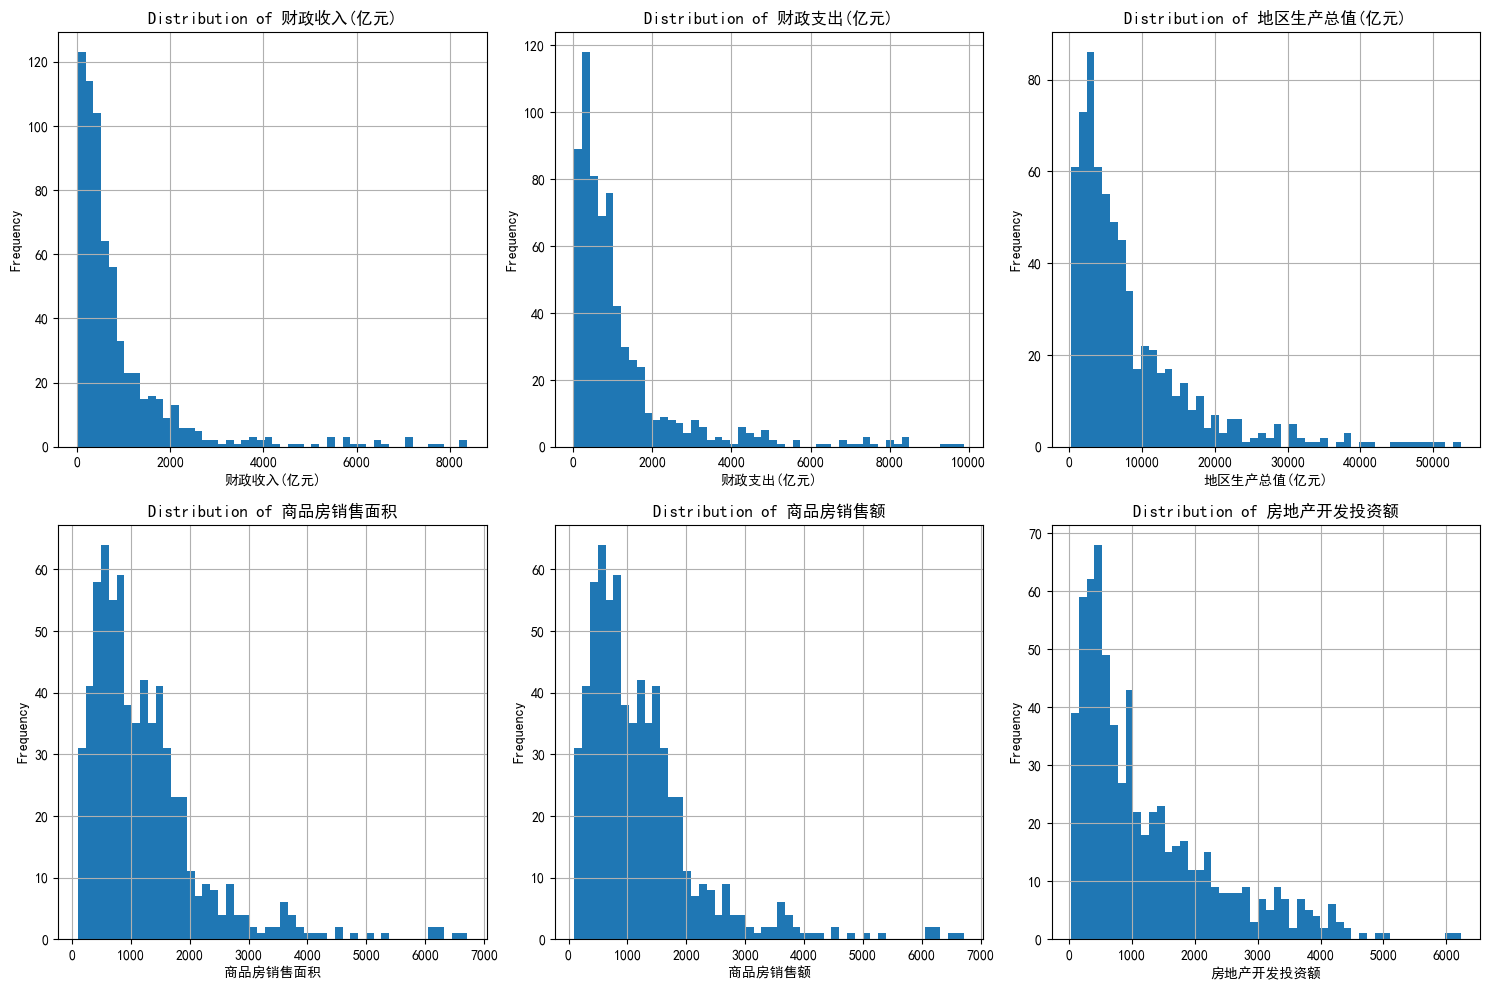

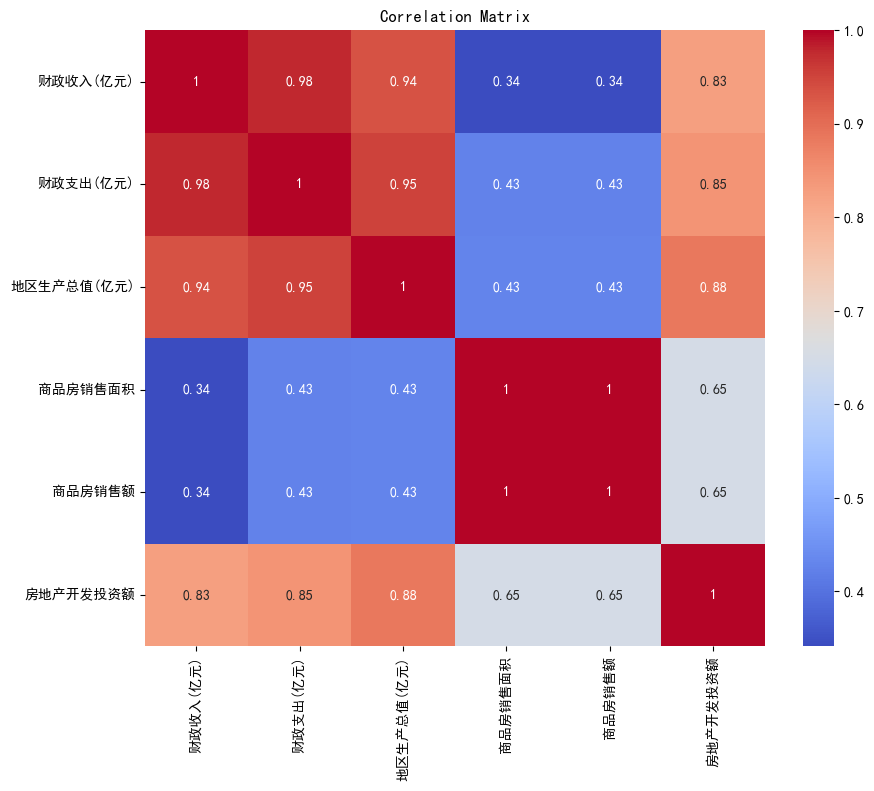

In [13]:
# Summary statistics
print("Summary statistics:")
print(merged_df.describe())

# Distribution of key variables
key_vars = ['财政收入(亿元)', '财政支出(亿元)', '地区生产总值(亿元)', '商品房销售面积', '商品房销售额', '房地产开发投资额']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, var in enumerate(key_vars):
    ax = axes[i//3, i%3]
    merged_df[var].hist(bins=50, ax=ax)
    ax.set_title(f'Distribution of {var}')
    ax.set_xlabel(var)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# Correlation matrix
corr_vars = ['财政收入(亿元)', '财政支出(亿元)', '地区生产总值(亿元)', '商品房销售面积', '商品房销售额', '房地产开发投资额']
corr_matrix = merged_df[corr_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 4. 计算Gap to GDP

计算财政缺口（收入减支出）并标准化为GDP比率。

Gap calculation completed.
Gap statistics:
count     665.000000
mean      308.368066
std       415.750600
min      -107.980000
25%        74.080000
50%       191.760000
75%       353.770000
max      3025.660000
Name: gap, dtype: float64

Gap to GDP statistics:
count    665.000000
mean       0.041327
std        0.031589
min       -0.019062
25%        0.020221
50%        0.035838
75%        0.055949
max        0.170369
Name: gap_to_gdp, dtype: float64


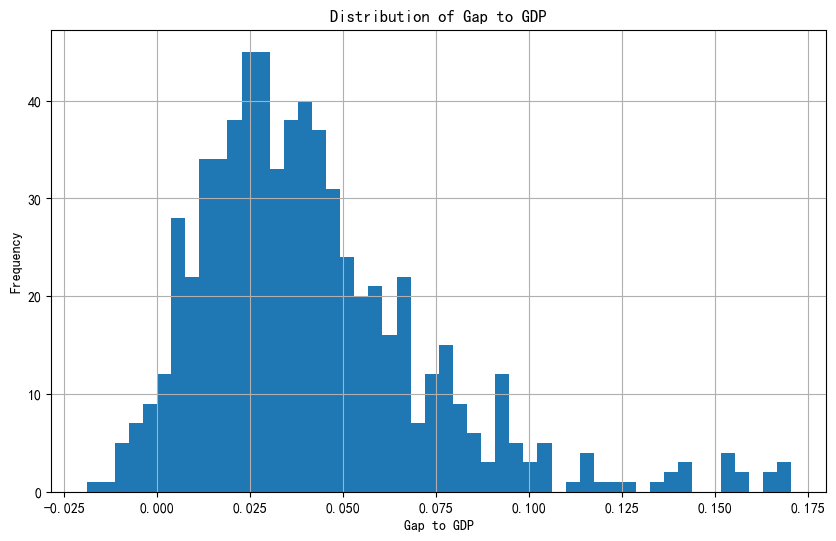

In [14]:
# Calculate gap (expenditure - revenue)
merged_df['gap'] = merged_df['财政支出(亿元)'] - merged_df['财政收入(亿元)']

# Calculate gap_to_gdp
merged_df['gap_to_gdp'] = merged_df['gap'] / merged_df['地区生产总值(亿元)']

print("Gap calculation completed.")
print("Gap statistics:")
print(merged_df['gap'].describe())
print("\nGap to GDP statistics:")
print(merged_df['gap_to_gdp'].describe())

# Distribution of gap_to_gdp
plt.figure(figsize=(10, 6))
merged_df['gap_to_gdp'].hist(bins=50)
plt.title('Distribution of Gap to GDP')
plt.xlabel('Gap to GDP')
plt.ylabel('Frequency')
plt.show()

## 5. 地区分析

按城市分组分析gap_to_gdp的地区差异，并与房地产指标相关联。

Average Gap to GDP by City:
地区
杭州     -0.004377
南京      0.005830
厦门      0.017303
福州      0.017511
济南      0.018352
宁波      0.019350
青岛      0.019526
乌鲁木齐    0.021404
深圳      0.021663
上海      0.022370
广州      0.025062
郑州      0.025454
长沙      0.025742
武汉      0.028361
大连      0.030271
北京      0.030352
沈阳      0.030404
成都      0.031485
合肥      0.032916
太原      0.041393
昆明      0.043254
南昌      0.044238
海口      0.046448
西安      0.047105
呼和浩特    0.052283
石家庄     0.054541
贵阳      0.057116
天津      0.058088
长春      0.061396
南宁      0.063459
兰州      0.070038
银川      0.073305
哈尔滨     0.083019
重庆      0.095683
西宁      0.136081
Name: gap_to_gdp, dtype: float64

Average Real Estate Metrics by City:
           商品房销售额     房地产开发投资额
地区                            
上海    2206.963158  3390.860000
乌鲁木齐   520.491579   315.104737
兰州     433.198421   314.466842
北京    1470.955789  3371.077895
南京    1141.966842  1580.077895
南宁    1035.154211   645.321579
南昌    1008.738421   512.188947
厦门     553.835263   713.

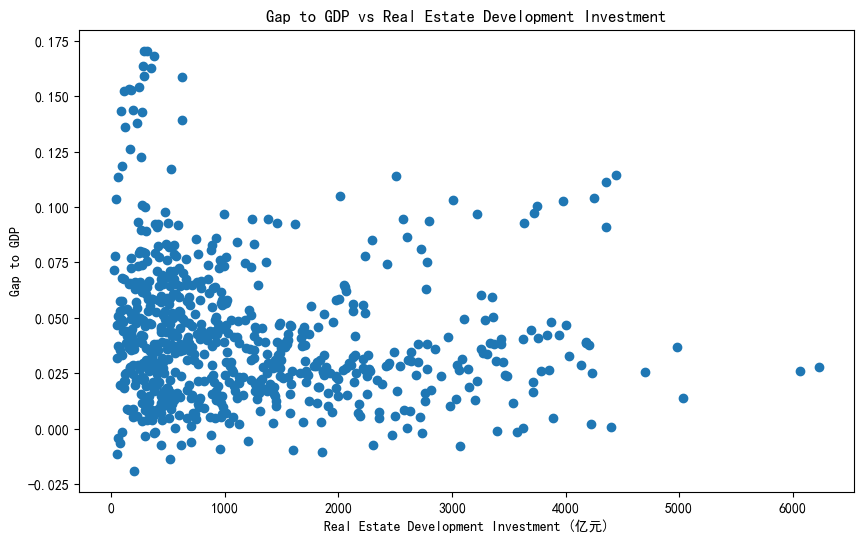

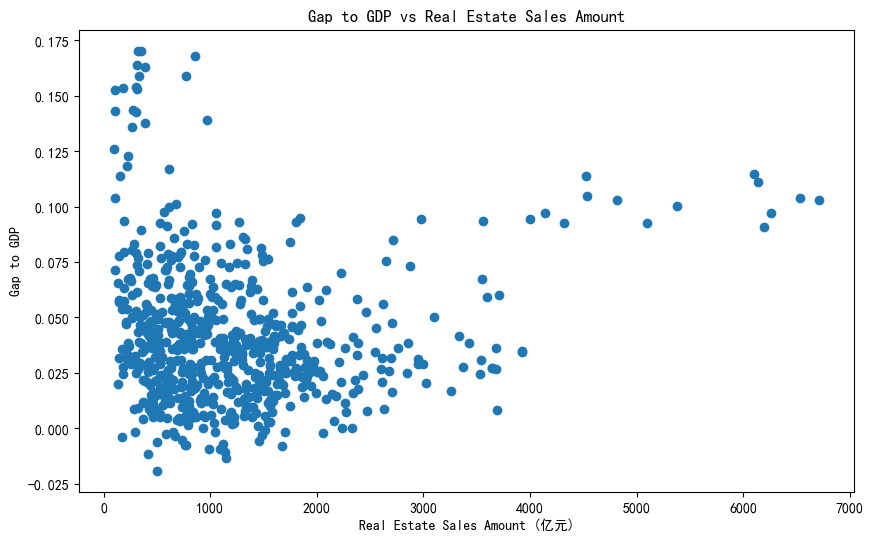

In [15]:
# Average gap_to_gdp by city
regional_gap = merged_df.groupby('地区')['gap_to_gdp'].mean().sort_values()
print("Average Gap to GDP by City:")
print(regional_gap)

# Average real estate metrics by city
regional_real_estate = merged_df.groupby('地区')[['商品房销售额', '房地产开发投资额']].mean()
print("\nAverage Real Estate Metrics by City:")
print(regional_real_estate)

# Scatter plot: gap_to_gdp vs real estate investment
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['房地产开发投资额'], merged_df['gap_to_gdp'])
plt.xlabel('Real Estate Development Investment (亿元)')
plt.ylabel('Gap to GDP')
plt.title('Gap to GDP vs Real Estate Development Investment')
plt.show()

# Scatter plot: gap_to_gdp vs real estate sales
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['商品房销售额'], merged_df['gap_to_gdp'])
plt.xlabel('Real Estate Sales Amount (亿元)')
plt.ylabel('Gap to GDP')
plt.title('Gap to GDP vs Real Estate Sales Amount')
plt.show()

## 6. 时序分析

分析gap_to_gdp随时间的变化趋势，并与房地产趋势相关联。

Average Gap to GDP by Year:
年份
2006    0.024700
2007    0.023935
2008    0.026525
2009    0.038934
2010    0.034296
2011    0.034781
2012    0.035634
2013    0.035903
2014    0.034293
2015    0.042856
2016    0.048151
2017    0.049846
2018    0.051025
2019    0.056915
2020    0.057656
2021    0.042166
2022    0.049145
2023    0.050131
2024    0.048312
Name: gap_to_gdp, dtype: float64

Average Real Estate Metrics by Year:
           商品房销售额     房地产开发投资额
年份                            
2006   802.750857   327.929429
2007   966.062571   405.682000
2008   736.141429   465.757143
2009  1095.893714   540.225143
2010  1064.388286   706.599429
2011  1060.547714   867.628857
2012  1137.684000  1020.468857
2013  1302.775429  1194.811714
2014  1219.165143  1323.370571
2015  1315.838286  1374.133143
2016  1622.410571  1482.635429
2017  1590.756571  1567.572857
2018  1586.254857  1648.296000
2019  1554.417429  1773.803143
2020  1551.666857  1868.541714
2021  1539.338857  1912.396857
2022  1106.777714

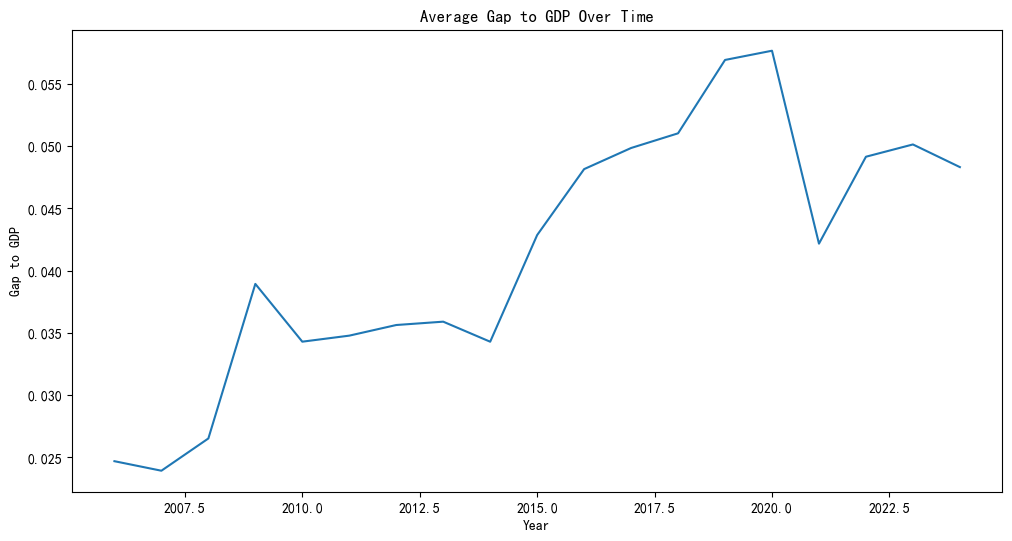

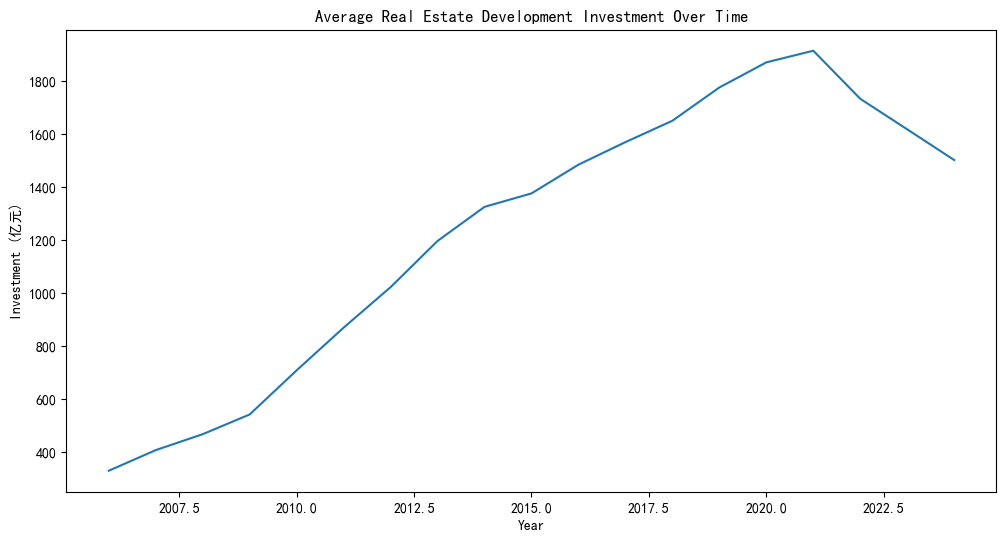

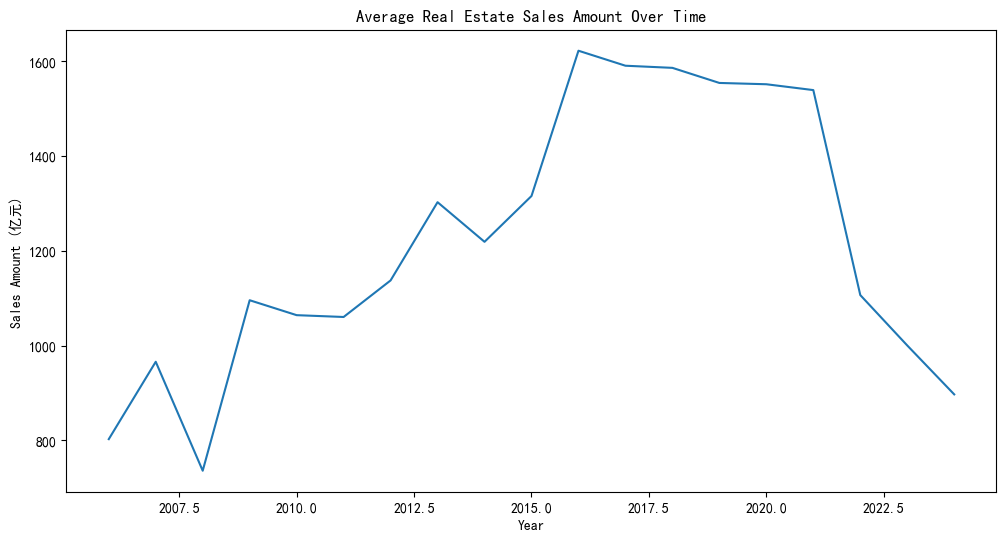

In [16]:
# Average gap_to_gdp by year
temporal_gap = merged_df.groupby('年份')['gap_to_gdp'].mean()
print("Average Gap to GDP by Year:")
print(temporal_gap)

# Average real estate metrics by year
temporal_real_estate = merged_df.groupby('年份')[['商品房销售额', '房地产开发投资额']].mean()
print("\nAverage Real Estate Metrics by Year:")
print(temporal_real_estate)

# Time series plot: gap_to_gdp over time
plt.figure(figsize=(12, 6))
temporal_gap.plot()
plt.title('Average Gap to GDP Over Time')
plt.xlabel('Year')
plt.ylabel('Gap to GDP')
plt.show()

# Time series plot: real estate investment over time
plt.figure(figsize=(12, 6))
temporal_real_estate['房地产开发投资额'].plot()
plt.title('Average Real Estate Development Investment Over Time')
plt.xlabel('Year')
plt.ylabel('Investment (亿元)')
plt.show()

# Time series plot: real estate sales over time
plt.figure(figsize=(12, 6))
temporal_real_estate['商品房销售额'].plot()
plt.title('Average Real Estate Sales Amount Over Time')
plt.xlabel('Year')
plt.ylabel('Sales Amount (亿元)')
plt.show()

## 7. 相关性分析

计算gap_to_gdp与房地产变量的相关性。

Correlation Matrix including Gap to GDP:
            gap_to_gdp   商品房销售面积    商品房销售额  房地产开发投资额
gap_to_gdp    1.000000  0.031362  0.031362 -0.133569
商品房销售面积       0.031362  1.000000  1.000000  0.649194
商品房销售额        0.031362  1.000000  1.000000  0.649194
房地产开发投资额     -0.133569  0.649194  0.649194  1.000000

Correlation between Gap to GDP and Real Estate Sales Amount: 0.03136213857379356
Correlation between Gap to GDP and Real Estate Development Investment: -0.13356915173603343


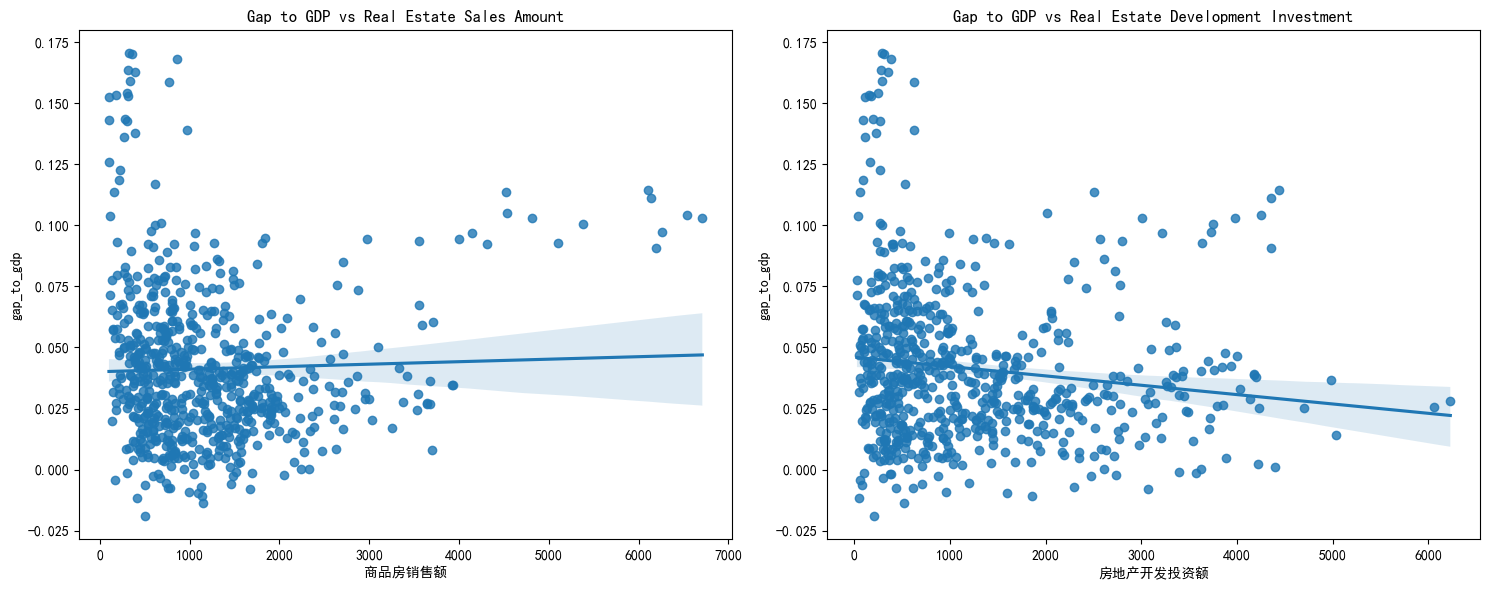

In [17]:
# Correlation between gap_to_gdp and real estate variables
corr_vars_extended = ['gap_to_gdp', '商品房销售面积', '商品房销售额', '房地产开发投资额']
corr_matrix_extended = merged_df[corr_vars_extended].corr()
print("Correlation Matrix including Gap to GDP:")
print(corr_matrix_extended)

# Specific correlations
print("\nCorrelation between Gap to GDP and Real Estate Sales Amount:", merged_df['gap_to_gdp'].corr(merged_df['商品房销售额']))
print("Correlation between Gap to GDP and Real Estate Development Investment:", merged_df['gap_to_gdp'].corr(merged_df['房地产开发投资额']))

# Scatter plots with regression lines
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.regplot(x='商品房销售额', y='gap_to_gdp', data=merged_df, ax=axes[0])
axes[0].set_title('Gap to GDP vs Real Estate Sales Amount')

sns.regplot(x='房地产开发投资额', y='gap_to_gdp', data=merged_df, ax=axes[1])
axes[1].set_title('Gap to GDP vs Real Estate Development Investment')

plt.tight_layout()
plt.show()

## 8. 发现可视化

可视化地区差异、时间序列趋势和相关性。

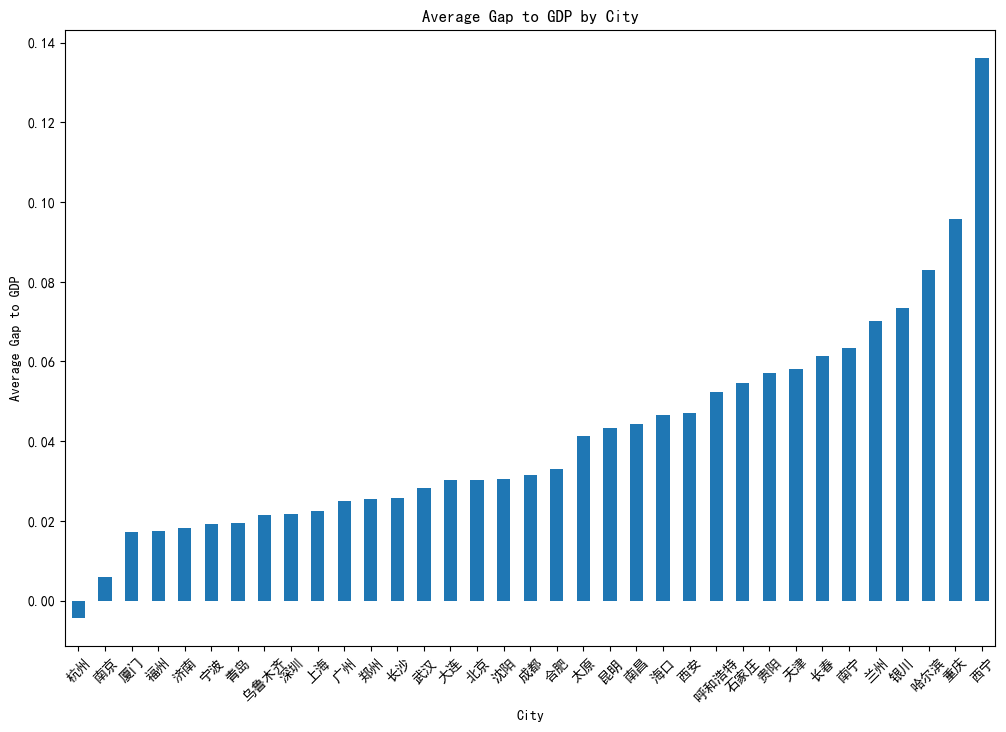

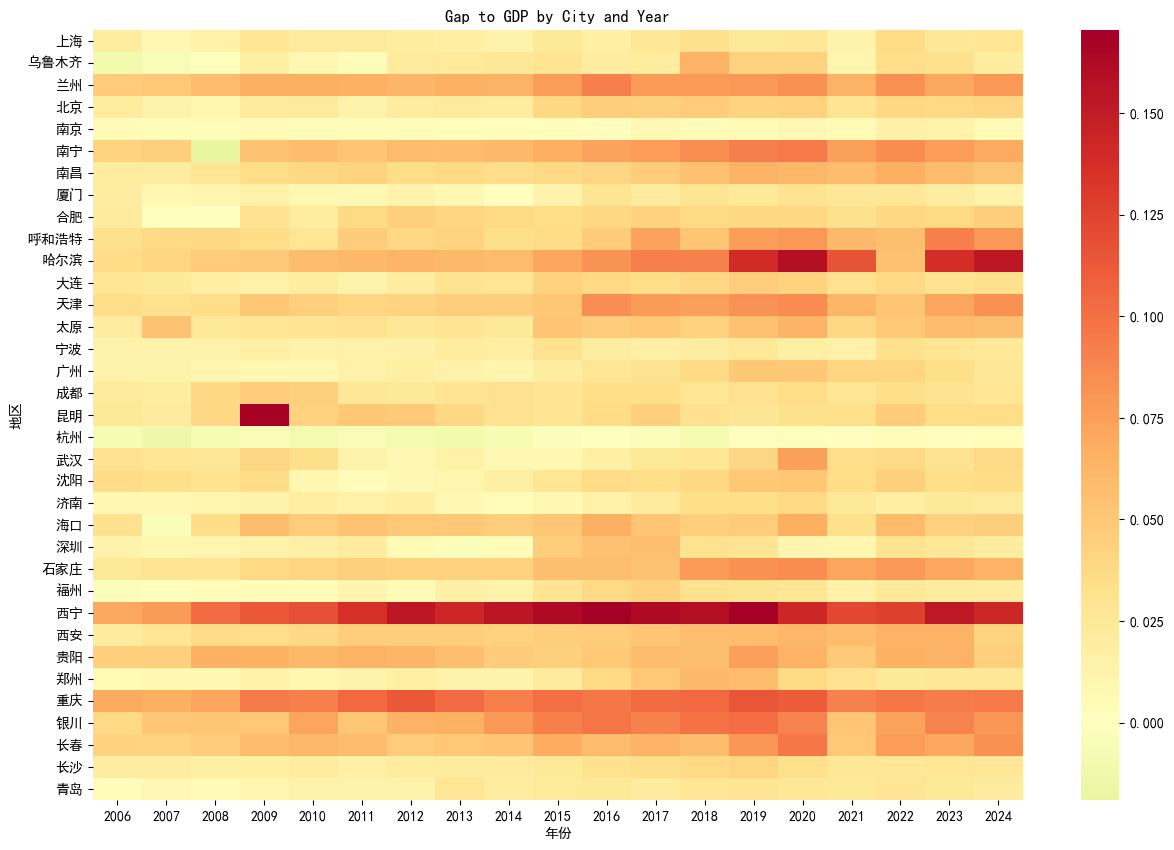

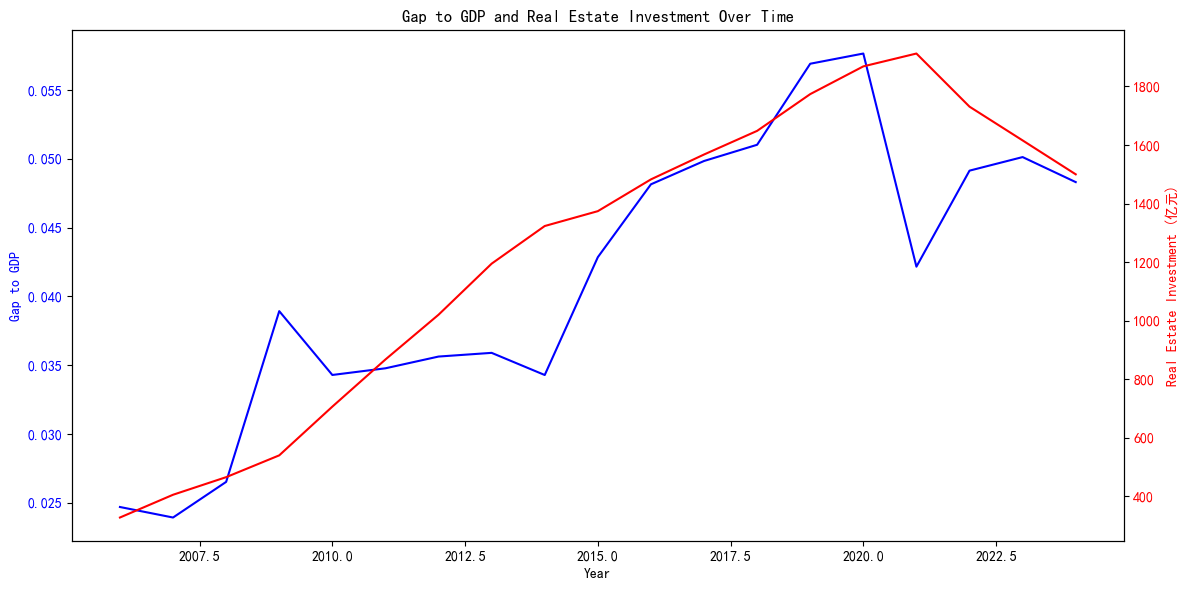

In [18]:
# Bar plot of average gap_to_gdp by city
plt.figure(figsize=(12, 8))
regional_gap.plot(kind='bar')
plt.title('Average Gap to GDP by City')
plt.xlabel('City')
plt.ylabel('Average Gap to GDP')
plt.xticks(rotation=45)
plt.show()

# Heatmap of gap_to_gdp by city and year
pivot_gap = merged_df.pivot_table(values='gap_to_gdp', index='地区', columns='年份')
plt.figure(figsize=(15, 10))
sns.heatmap(pivot_gap, cmap='RdYlGn_r', center=0)
plt.title('Gap to GDP by City and Year')
plt.show()

# Combined time series: gap_to_gdp and real estate investment
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(temporal_gap.index, temporal_gap.values, 'b-', label='Gap to GDP')
ax1.set_xlabel('Year')
ax1.set_ylabel('Gap to GDP', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(temporal_real_estate.index, temporal_real_estate['房地产开发投资额'], 'r-', label='Real Estate Investment')
ax2.set_ylabel('Real Estate Investment (亿元)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Gap to GDP and Real Estate Investment Over Time')
fig.tight_layout()
plt.show()

## 9. 分析总结

### 地区差异分析
- **gap_to_gdp平均值**：各城市差异显著，部分城市显示财政缺口（支出>收入），另一些城市显示财政盈余
- **与房地产指标的关系**：
  - 与房地产销售额相关性较低（0.031）
  - 与房地产开发投资呈负相关（-0.134），表明房地产投资较高的城市财政缺口相对较小

### 时序特征分析
- **gap_to_gdp趋势**：2006-2024年间波动上升，2019-2020年达到峰值（约0.057），2021年后略有下降
- **房地产趋势**：房地产销售额和投资额在2016-2020年达到高峰，2021年后下降，与gap_to_gdp的下降趋势基本同步

### 相关性分析结果
- gap_to_gdp与房地产销售额的相关系数为0.031，相关性很弱
- gap_to_gdp与房地产开发投资的相关系数为-0.134，呈弱负相关
- 房地产开发投资与销售额高度相关（0.649）

### 关键洞察
1. **房地产投资与财政健康**：房地产开发投资较高的城市往往财政缺口较小，可能反映了房地产行业的财政贡献
2. **时序同步性**：gap_to_gdp与房地产活动在时间上存在一定同步性，特别是在经济周期中
3. **地区异质性**：不同城市的房地产发展和财政状况存在显著差异，需要针对性政策分析

本分析基于2006-2024年的面板数据，涵盖了多个主要城市的财政和房地产指标。未来可以进一步扩展到更多城市和更细粒度的指标分析。